In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

\

CNN

In [ ]:
#import librosa
#import librosa.display
import numpy as np
import pandas as pd
!pip install ffmpeg
import ffmpeg as ff

import os
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
import random
import cv2
import pickle
import datetime
from PIL import Image
import glob

  Created wheel for ffmpeg: filename=ffmpeg-1.4-py3-none-any.whl size=6083 sha256=8d12f614f2dac4b5033ea32d8041c5b703cf6f43e825a0dcac3853834401e3fa
  Stored in directory: /root/.cache/pip/wheels/64/80/6e/caa3e16deb0267c3cbfd36862058a724144e19fdb9eb03af0f
Successfully built ffmpeg


In [ ]:
!unzip gdrive/My\ Drive/project.zip > /dev/null




replace project/.ipynb_checkpoints/notebook1-checkpoint.ipynb? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


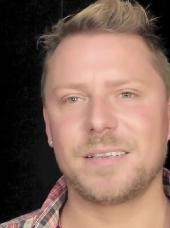

In [ ]:
import tensorflow as tf
img = tf.keras.preprocessing.image.load_img('project/videos/-6otZ7M-Mro.003.mp4/-6otZ7M-Mro.003.mp4-00001.jpg')
img

In [ ]:
data=pd.read_csv('project/data.csv')
datavalid=pd.read_csv('project/datavalid.csv')
datatest=pd.read_csv('project/datatest.csv')

In [ ]:
def resize_image(image, new_size) -> np.ndarray:
    return cv2.resize(image, new_size, interpolation = cv2.INTER_AREA)

In [ ]:
def crop_image_window(image, training) -> np.ndarray:
    height, width, _ = image.shape
    if training:
        MAX_N = height - 128
        MAX_M = width - 128
        rand_N_index, rand_M_index = random.randint(0, MAX_N) , random.randint(0, MAX_M)
        return image[rand_N_index:(rand_N_index+128),rand_M_index:(rand_M_index+128),:]
    else:
        N_index = (height - 128) // 2
        M_index = (width - 128) // 2
        return image[N_index:(N_index+128),M_index:(M_index+128),:]

In [ ]:
ValueExtraversion=[]
ValueExtraversion=data['ValueExtraversion'].values
#print(ValueExtraversion)
ValueAgreeableness=[]
ValueAgreeableness=data['ValueAgreeableness'].values
#print(ValueAgreeableness)
ValueConscientiousness=[]
ValueConscientiousness=data['ValueConscientiousness'].values
#print(ValueConscientiousness)
ValueNeurotisicm=[]
ValueNeurotisicm=data['ValueNeurotisicm'].values
#print(ValueNeurotisicm)
ValueOpenness=[]
ValueOpenness=data['ValueOpenness'].values
#print(ValueOpenness)
dict1={}
z=0
w=0
videos=[]
videos=data['VideoName'].values
features=['ValueExtraversion', 'ValueAgreeableness',
       'ValueConscientiousness', 'ValueNeurotisicm', 'ValueOpenness']
features1=[ValueExtraversion, ValueAgreeableness,
       ValueConscientiousness, ValueNeurotisicm, ValueOpenness]
for x in features:
    y={}
    w=0
    for filename in videos:
        y[filename]=features1[z][w]
        w+=1
    dict1[x]=y
    z+=1

print(dict1)

{'ValueExtraversion': {'04oq2yrBwMg.000.mp4': 0.317757009, '04oq2yrBwMg.001.mp4': 0.411214953, '04oq2yrBwMg.003.mp4': 0.38317757, '04oq2yrBwMg.005.mp4': 0.420560748, '05l5bteT_qA.004.mp4': 0.439252336, '0fMw9o1v2tY.002.mp4': 0.280373832, '0gv5Z0qt2jc.005.mp4': 0.224299065, '0iQIfGnKflc.001.mp4': 0.588785047, '0kg6pmbSN6A.001.mp4': 0.24299065399999997, '0MB91ku0eEw.003.mp4': 0.598130841, '0mym1CooiTE.002.mp4': 0.6635514020000001, '0mym1CooiTE.005.mp4': 0.598130841, '0ObEtA6Q8vU.004.mp4': 0.6261682239999999, '0SS47KwVOQ4.000.mp4': 0.439252336, '0tse0Fsy_rg.000.mp4': 0.23364486, '0tse0Fsy_rg.003.mp4': 0.392523364, '0u56Q_QmxIM.001.mp4': 0.411214953, '0VnZngec8sc.002.mp4': 0.23364486, '0VnZngec8sc.004.mp4': 0.448598131, '0Wr69VD_oXI.004.mp4': 0.579439252, '0zJcYnsh55g.002.mp4': 0.48598130799999995, '0zJcYnsh55g.003.mp4': 0.560747664, '0ZK5jQAvhFo.004.mp4': 0.551401869, '12Ezy1y1cWY.004.mp4': 0.140186916, '12lqQE6oPNE.002.mp4': 0.7102803740000001, '176vWywoq9E.003.mp4': 0.364485981, '19pTUX

In [ ]:
ValueExtraversion=[]
ValueExtraversion=datavalid['ValueExtraversion'].values
#print(ValueExtraversion)
ValueAgreeableness=[]
ValueAgreeableness=datavalid['ValueAgreeableness'].values
#print(ValueAgreeableness)
ValueConscientiousness=[]
ValueConscientiousness=datavalid['ValueConscientiousness'].values
#print(ValueConscientiousness)
ValueNeurotisicm=[]
ValueNeurotisicm=datavalid['ValueNeurotisicm'].values
#print(ValueNeurotisicm)
ValueOpenness=[]
ValueOpenness=datavalid['ValueOpenness'].values
#print(ValueOpenness)
dictvalid={}
z=0
w=0
videos=[]
videos=datavalid['VideoName'].values
features=['ValueExtraversion', 'ValueAgreeableness',
       'ValueConscientiousness', 'ValueNeurotisicm', 'ValueOpenness']
features1=[ValueExtraversion, ValueAgreeableness,
       ValueConscientiousness, ValueNeurotisicm, ValueOpenness]
for x in features:
    y={}
    w=0
    for filename in videos:
        y[filename]=features1[z][w]
        w+=1
    dictvalid[x]=y
    z+=1

print(dictvalid)

{'ValueExtraversion': {'Ymqszjv54.001.mp4': 1.0, '-9BZ8A9U7TE.004.mp4': 0.5046728970000001, '-55DRRMTppE.000.mp4': 0.579439252, '-6otZ7M-Mro.001.mp4': 0.46728972, '-IK--4uz5ZY.000.mp4': 0.579439252, '1RMdiCbNNh4.003.mp4': 0.186915888, '1UaqZEUUk9I.000.mp4': 0.551401869, '2f7rLXwzP3s.002.mp4': 0.644859813, '3DURnr95fMg.002.mp4': 0.308411215, '3IV-sr3NOUo.004.mp4': 0.24299065399999997, 'IK--4uz5ZY.003.mp4': 0.644859813, '0C6i34q2-f8.001.mp4': 0.373831776, '0ObEtA6Q8vU.003.mp4': 0.579439252, '0fMw9o1v2tY.003.mp4': 0.224299065, '0gv5Z0qt2jc.004.mp4': 0.186915888, '4fN-DKUzgWQ.002.mp4': 0.560747664, '4KD3XCMsIBs.002.mp4': 0.523364486, '5bi_PM3XMEQ.004.mp4': 0.607476636, '5hFRSHAis2E.001.mp4': 0.672897196, '5hFRSHAis2E.004.mp4': 0.523364486, '6JfSPPVUgIg.001.mp4': 0.23364486, '6l0RBbxg4fk.001.mp4': 0.682242991, '6LKbPUX03sY.002.mp4': 0.373831776, '6M8OQNo64Tc.000.mp4': 0.224299065, '6nbxAP_ZKQQ.004.mp4': 0.551401869, '6NjuNY4LfQc.001.mp4': 0.7009345790000001, '6NjuNY4LfQc.002.mp4': 0.3457943

In [ ]:
ValueExtraversion=[]
ValueExtraversion=datatest['ValueExtraversion'].values
#print(ValueExtraversion)
ValueAgreeableness=[]
ValueAgreeableness=datatest['ValueAgreeableness'].values
#print(ValueAgreeableness)
ValueConscientiousness=[]
ValueConscientiousness=datatest['ValueConscientiousness'].values
#print(ValueConscientiousness)
ValueNeurotisicm=[]
ValueNeurotisicm=datatest['ValueNeurotisicm'].values
#print(ValueNeurotisicm)
ValueOpenness=[]
ValueOpenness=datatest['ValueOpenness'].values
#print(ValueOpenness)
dicttest={}
z=0
w=0
videos=[]
videos=datatest['VideoName'].values
features=['ValueExtraversion', 'ValueAgreeableness',
       'ValueConscientiousness', 'ValueNeurotisicm', 'ValueOpenness']
features1=[ValueExtraversion, ValueAgreeableness,
       ValueConscientiousness, ValueNeurotisicm, ValueOpenness]
for x in features:
    y={}
    w=0
    for filename in videos:
        y[filename]=features1[z][w]
        w+=1
    dicttest[x]=y
    z+=1

print(dicttest)

{'ValueExtraversion': {'0a5FOYBAIcc.001.mp4': 0.429906542, '0mym1CooiTE.002.mp4': 0.6635514020000001, '1dOaM7zWPo8.002.mp4': 0.439252336, '1m67onLoRwY.001.mp4': 0.32710280399999997, '1mdMhaq5p4w.000.mp4': 0.420560748, '1pMNczHCXPc.000.mp4': 0.411214953, '2HE6cw3HFPk.004.mp4': 0.6355140189999999, '2KSBoJZMcMU.000.mp4': 0.448598131, '04oq2yrBwMg.000.mp4': 0.317757009, 'LDYe7OXZU.004.mp4': 0.560747664, 'R2SZu3SYgM.004.mp4': 0.336448598, '05l5bteT_qA.000.mp4': 0.61682243, '0VnZngec8sc.003.mp4': 0.61682243, '0gv5Z0qt2jc.000.mp4': 0.14953271, '0hWbtuRVUgM.001.mp4': 0.224299065, '3J7Cl3FXs1o.003.mp4': 0.7009345790000001, '3JzvXA-Zfbs.004.mp4': 0.5046728970000001, '4bDOetaLvZs.000.mp4': 0.411214953, '4b-LkHBGWp4.005.mp4': 0.7009345790000001, '4fN-DKUzgWQ.000.mp4': 0.738317757, '4lH5nLSwmoM.002.mp4': 0.35514018700000005, '4lH5nLSwmoM.004.mp4': 0.495327103, '4lIbWq27O84.004.mp4': 0.48598130799999995, '4lIbWq27O84.005.mp4': 0.364485981, '4lj66h4CXI8.001.mp4': 0.6355140189999999, '4lj66h4CXI8.004.

In [ ]:
def reading_label_data(file_name, dictionary) -> np.ndarray:
    extracted_data = [float(dictionary[label][file_name]) for label in features]
    print(np.stack(extracted_data).reshape(5,1))
    return np.stack(extracted_data).reshape(5,1)

In [ ]:
x=0

In [ ]:
def preprocessing_input(file_path, file_name, dict1, training):
    #Video
    print(file_path)
    image_list = []
    for filename in glob.glob(file_path):
        print(filename) #assuming gif
        im=Image.open(filename)
        np_img = np.array(im)
        #print(type(np_img))
        #print(np_img.shape)
        image_list.append(np_img)
        #print((image_list))
    list1=[]
    
    resized_images = [resize_image(image= im, new_size= (248,140)) for im in image_list]
    cropped_images = [crop_image_window(resi,training) / 255.0 for resi in resized_images]
    preprocessed_video = np.stack(cropped_images)
    #print(type(preprocessed_video))
    #Ground Truth
    video_gt = reading_label_data(file_name, dict1)
    del resized_images, cropped_images
    print(type(video_gt))
    print(type(preprocessed_video))  
    return (preprocessed_video, video_gt)

In [ ]:
def reshape_to_expected_input(dataset):
    x1_list = []
    y_list = []
    for i in range(0,len(dataset)):
        
        x1_list.append(dataset[i][0])
        y_list.append(dataset[i][1])
    return (np.stack(x1_list),np.stack(y_list))

In [ ]:
training_set_data = []
path = r"project/videos"

for filename in data['VideoName']:
  filePath = path+'/'+filename+"/*.jpg"
  filepath1=path+'/'+filename
  file = pathlib.Path(filepath1)
  if(file.exists()):
    training_set_data.append(preprocessing_input(filePath, filename,dict1,True))
print(len(training_set_data))

project/videos/04oq2yrBwMg.000.mp4/*.jpg
project/videos/04oq2yrBwMg.000.mp4/04oq2yrBwMg.000.mp4-00001.jpg
project/videos/04oq2yrBwMg.000.mp4/04oq2yrBwMg.000.mp4-00241.jpg
project/videos/04oq2yrBwMg.000.mp4/04oq2yrBwMg.000.mp4-00161.jpg
project/videos/04oq2yrBwMg.000.mp4/04oq2yrBwMg.000.mp4-00081.jpg
[[0.31775701]
 [0.27472527]
 [0.20388349]
 [0.1875    ]
 [0.36666667]]
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
project/videos/04oq2yrBwMg.003.mp4/*.jpg
project/videos/04oq2yrBwMg.003.mp4/04oq2yrBwMg.003.mp4-00241.jpg
project/videos/04oq2yrBwMg.003.mp4/04oq2yrBwMg.003.mp4-00001.jpg
project/videos/04oq2yrBwMg.003.mp4/04oq2yrBwMg.003.mp4-00081.jpg
project/videos/04oq2yrBwMg.003.mp4/04oq2yrBwMg.003.mp4-00161.jpg
[[0.38317757]
 [0.52747253]
 [0.32038835]
 [0.41666667]
 [0.5       ]]
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
project/videos/04oq2yrBwMg.005.mp4/*.jpg
project/videos/04oq2yrBwMg.005.mp4/04oq2yrBwMg.005.mp4-00241.jpg
project/videos/04oq2yrBwMg.005.mp4/04oq2yrBwMg.005.mp4

In [ ]:
def reshape_to_expected_input(dataset):
    
    
    x1_list = []
    y_list = []
    for i in range(0,len(dataset)):
        
        x1_list.append(dataset[i][0])
        y_list.append(dataset[i][1])
    return (np.stack(x1_list),np.stack(y_list))

In [ ]:
validation_set_data = []
path = r"project/videosvalid"

for filename in datavalid['VideoName']:
    filePath = path+'/'+filename+"/*.jpg"
    filepath1=path+'/'+filename
    file = pathlib.Path(filepath1)
    if(file.exists()):
      validation_set_data.append(preprocessing_input(filePath,filename, dictvalid, training= False))
print(len(validation_set_data))

project/videosvalid/Ymqszjv54.001.mp4/*.jpg
project/videosvalid/Ymqszjv54.001.mp4/Ymqszjv54.001.mp4-00081.jpg
project/videosvalid/Ymqszjv54.001.mp4/Ymqszjv54.001.mp4-00241.jpg
project/videosvalid/Ymqszjv54.001.mp4/Ymqszjv54.001.mp4-00161.jpg
project/videosvalid/Ymqszjv54.001.mp4/Ymqszjv54.001.mp4-00001.jpg
[[1. ]
 [0.2]
 [0.5]
 [0.6]
 [0.7]]
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
project/videosvalid/-9BZ8A9U7TE.004.mp4/*.jpg
project/videosvalid/-9BZ8A9U7TE.004.mp4/-9BZ8A9U7TE.004.mp4-00081.jpg
project/videosvalid/-9BZ8A9U7TE.004.mp4/-9BZ8A9U7TE.000.mp4-00161.jpg
project/videosvalid/-9BZ8A9U7TE.004.mp4/-9BZ8A9U7TE.000.mp4-00001.jpg
project/videosvalid/-9BZ8A9U7TE.004.mp4/-9BZ8A9U7TE.000.mp4-00241.jpg
[[0.5046729 ]
 [0.6043956 ]
 [0.41747573]
 [0.59375   ]
 [0.61111111]]
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
project/videosvalid/-55DRRMTppE.000.mp4/*.jpg
project/videosvalid/-55DRRMTppE.000.mp4/-55DRRMTppE.000.mp4-00161.jpg
project/videosvalid/-55DRRMTppE.000.mp4/-55DRRM

In [ ]:
import pathlib




In [ ]:
test_set_data = []
path = r"project/videostest"

for filename in datatest['VideoName']:
    filePath = path+'/'+filename+"/*.jpg"
    filepath1=path+'/'+filename
    file = pathlib.Path(filepath1)
    if(file.exists()):
      test_set_data.append(preprocessing_input(filePath, filename, dicttest, training= False))
print(len(test_set_data))

project/videostest/0a5FOYBAIcc.001.mp4/*.jpg
project/videostest/0a5FOYBAIcc.001.mp4/0a5FOYBAIcc.001.mp4-00001.jpg
project/videostest/0a5FOYBAIcc.001.mp4/0a5FOYBAIcc.001.mp4-00081.jpg
project/videostest/0a5FOYBAIcc.001.mp4/0a5FOYBAIcc.001.mp4-00161.jpg
project/videostest/0a5FOYBAIcc.001.mp4/0a5FOYBAIcc.001.mp4-00241.jpg
[[0.42990654]
 [0.43956044]
 [0.33009709]
 [0.34375   ]
 [0.48888889]]
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
project/videostest/0mym1CooiTE.002.mp4/*.jpg
project/videostest/0mym1CooiTE.002.mp4/0mym1CooiTE.002.mp4-00081.jpg
project/videostest/0mym1CooiTE.002.mp4/0mym1CooiTE.002.mp4-00001.jpg
project/videostest/0mym1CooiTE.002.mp4/0mym1CooiTE.002.mp4-00241.jpg
project/videostest/0mym1CooiTE.002.mp4/0mym1CooiTE.002.mp4-00161.jpg
[[0.6635514 ]
 [0.69230769]
 [0.7184466 ]
 [0.76041667]
 [0.77777778]]
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
project/videostest/1dOaM7zWPo8.002.mp4/*.jpg
project/videostest/1dOaM7zWPo8.002.mp4/1dOaM7zWPo8.002.mp4-00241.jpg
projec

In [ ]:
print(dicttest)
print(datatest)

{'ValueExtraversion': {'0a5FOYBAIcc.001.mp4': 0.429906542, '0mym1CooiTE.002.mp4': 0.6635514020000001, '1dOaM7zWPo8.002.mp4': 0.439252336, '1m67onLoRwY.001.mp4': 0.32710280399999997, '1mdMhaq5p4w.000.mp4': 0.420560748, '1pMNczHCXPc.000.mp4': 0.411214953, '2HE6cw3HFPk.004.mp4': 0.6355140189999999, '2KSBoJZMcMU.000.mp4': 0.448598131, '04oq2yrBwMg.000.mp4': 0.317757009, 'LDYe7OXZU.004.mp4': 0.560747664, 'R2SZu3SYgM.004.mp4': 0.336448598, '05l5bteT_qA.000.mp4': 0.61682243, '0VnZngec8sc.003.mp4': 0.61682243, '0gv5Z0qt2jc.000.mp4': 0.14953271, '0hWbtuRVUgM.001.mp4': 0.224299065, '3J7Cl3FXs1o.003.mp4': 0.7009345790000001, '3JzvXA-Zfbs.004.mp4': 0.5046728970000001, '4bDOetaLvZs.000.mp4': 0.411214953, '4b-LkHBGWp4.005.mp4': 0.7009345790000001, '4fN-DKUzgWQ.000.mp4': 0.738317757, '4lH5nLSwmoM.002.mp4': 0.35514018700000005, '4lH5nLSwmoM.004.mp4': 0.495327103, '4lIbWq27O84.004.mp4': 0.48598130799999995, '4lIbWq27O84.005.mp4': 0.364485981, '4lj66h4CXI8.001.mp4': 0.6355140189999999, '4lj66h4CXI8.004.

In [ ]:
train_input = reshape_to_expected_input(training_set_data)
print(type(train_input))
del training_set_data
validation_input = reshape_to_expected_input(dataset= validation_set_data)
del validation_set_data
test_input=reshape_to_expected_input(test_set_data)


<class 'tuple'>


In [ ]:
print(train_input[0])
print(train_input[1])

[[[[[0.32941176 0.25490196 0.20784314]
    [0.32156863 0.25098039 0.20392157]
    [0.30588235 0.23921569 0.2       ]
    ...
    [0.05098039 0.05098039 0.05098039]
    [0.01960784 0.01960784 0.01960784]
    [0.01176471 0.01176471 0.01176471]]

   [[0.28627451 0.21568627 0.17647059]
    [0.28627451 0.21960784 0.18431373]
    [0.28235294 0.22745098 0.21176471]
    ...
    [0.06666667 0.06666667 0.06666667]
    [0.06666667 0.06666667 0.06666667]
    [0.04313725 0.04313725 0.04313725]]

   [[0.28627451 0.21960784 0.18039216]
    [0.28235294 0.22352941 0.19215686]
    [0.2745098  0.23137255 0.22352941]
    ...
    [0.01568627 0.01568627 0.01568627]
    [0.01960784 0.01960784 0.01960784]
    [0.01568627 0.01568627 0.01568627]]

   ...

   [[0.81960784 0.63921569 0.5372549 ]
    [0.82352941 0.64313725 0.5372549 ]
    [0.83529412 0.65098039 0.54117647]
    ...
    [0.76862745 0.6        0.4745098 ]
    [0.77647059 0.60784314 0.48235294]
    [0.77647059 0.60392157 0.48627451]]

   [[0.81960784 

In [ ]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Input, LSTM, Bidirectional, Lambda, Dropout, Concatenate
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import TimeDistributed

In [ ]:
from keras.applications import vgg16

In [ ]:
visual_model = Input(shape=(4,128,128,3))

cnn = vgg16.VGG16(weights="imagenet", include_top=False, pooling='max')
cnn.trainable = False

58900480/58889256 [==============================] - 0s 0us/step


In [ ]:
encoded_frame = TimeDistributed(Lambda(lambda x: cnn(x)))(visual_model)
encoded_vid = LSTM(64)(encoded_frame)

visual_subnetwork = Model(inputs=visual_model,outputs=encoded_vid)

The following Variables were used a Lambda layer's call (lambda), but
are not present in its tracked objects:
  <tf.Variable 'block1_conv1/kernel:0' shape=(3, 3, 3, 64) dtype=float32>
  <tf.Variable 'block1_conv1/bias:0' shape=(64,) dtype=float32>
  <tf.Variable 'block1_conv2/kernel:0' shape=(3, 3, 64, 64) dtype=float32>
  <tf.Variable 'block1_conv2/bias:0' shape=(64,) dtype=float32>
  <tf.Variable 'block2_conv1/kernel:0' shape=(3, 3, 64, 128) dtype=float32>
  <tf.Variable 'block2_conv1/bias:0' shape=(128,) dtype=float32>
  <tf.Variable 'block2_conv2/kernel:0' shape=(3, 3, 128, 128) dtype=float32>
  <tf.Variable 'block2_conv2/bias:0' shape=(128,) dtype=float32>
  <tf.Variable 'block3_conv1/kernel:0' shape=(3, 3, 128, 256) dtype=float32>
  <tf.Variable 'block3_conv1/bias:0' shape=(256,) dtype=float32>
  <tf.Variable 'block3_conv2/kernel:0' shape=(3, 3, 256, 256) dtype=float32>
  <tf.Variable 'block3_conv2/bias:0' shape=(256,) dtype=float32>
  <tf.Variable 'block3_conv3/kernel:0' shape=(

In [ ]:
combined = visual_subnetwork.output
final1 = Dense(256, activation='relu')(combined)
final2 = Dense(5, activation='linear')(final1)

In [ ]:
combined_network = Model(inputs=[visual_model], outputs=final2)
combined_network.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 4, 128, 128, 3)]  0         
                                                                 
 time_distributed (TimeDistr  (None, 4, 512)           0         
 ibuted)                                                         
                                                                 
 lstm (LSTM)                 (None, 64)                147712    
                                                                 
 dense (Dense)               (None, 256)               16640     
                                                                 
 dense_1 (Dense)             (None, 5)                 1285      
                                                                 
Total params: 165,637
Trainable params: 165,637
Non-trainable params: 0
_____________________________________________________

In [ ]:
combined_network.compile(optimizer = 'adam',loss = 'mean_absolute_error',metrics=['mae'])

In [ ]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(patience=10)

In [ ]:
history = combined_network.fit(x = train_input[0],
                               y = train_input[1],
                               validation_data = (validation_input[0],validation_input[1]),
                               batch_size=1,
                               epochs = 20,
                               verbose = 1,
                               callbacks = [early_stopping])

Epoch 1/20
143/143 [==============================] - 124s 850ms/step - loss: 0.1465 - mae: 0.1465 - val_loss: 0.1559 - val_mae: 0.1559
Epoch 2/20
143/143 [==============================] - 118s 830ms/step - loss: 0.1169 - mae: 0.1169 - val_loss: 0.1526 - val_mae: 0.1526
Epoch 3/20
143/143 [==============================] - 117s 821ms/step - loss: 0.1060 - mae: 0.1060 - val_loss: 0.1548 - val_mae: 0.1548
Epoch 4/20
143/143 [==============================] - 117s 822ms/step - loss: 0.1078 - mae: 0.1078 - val_loss: 0.1564 - val_mae: 0.1564
Epoch 5/20
143/143 [==============================] - 117s 821ms/step - loss: 0.0966 - mae: 0.0966 - val_loss: 0.1575 - val_mae: 0.1575
Epoch 6/20
143/143 [==============================] - 117s 823ms/step - loss: 0.0863 - mae: 0.0863 - val_loss: 0.1632 - val_mae: 0.1632
Epoch 7/20
143/143 [==============================] - 117s 822ms/step - loss: 0.0842 - mae: 0.0842 - val_loss: 0.1595 - val_mae: 0.1595
Epoch 8/20
143/143 [============================

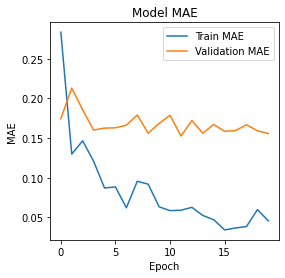

In [ ]:
plt.figure(figsize=(9,4))

plt.subplot(1,2,1)
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train MAE', 'Validation MAE'], loc='upper right')

In [ ]:
loss, mae = combined_network.evaluate(test_input[0],test_input[1], verbose=0)

print('Test loss: {}'.format(loss))

Test loss: 0.12864525616168976


In [ ]:
print('1-MAE: ' + str(1-mae))

1-MAE: 0.8713547438383102


In [ ]:
one_minus_mae_train = [1-maee for maee in history.history['mae']]
one_minus_mae_val = [1-maee for maee in history.history['val_mae']]

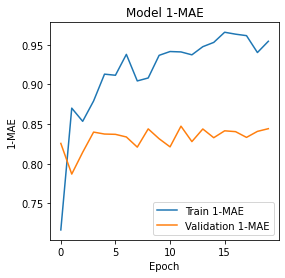

In [ ]:
plt.figure(figsize=(9,4))

plt.subplot(1,2,1)
plt.plot(one_minus_mae_train)
plt.plot(one_minus_mae_val)
plt.title('Model 1-MAE')
plt.ylabel('1-MAE')
plt.xlabel('Epoch')
plt.legend(['Train 1-MAE', 'Validation 1-MAE'], loc='lower right')

In [ ]:
print(len(test_set_data))

10


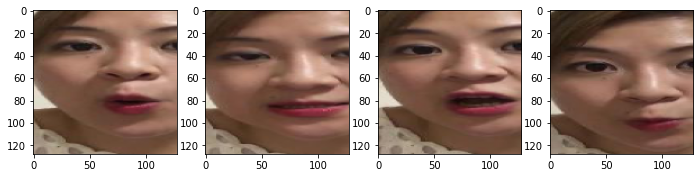

In [ ]:
images_to_plot = []
test_random_index = random.randint(0, len(test_set_data)-1)
images_to_plot.extend([(test_set_data[test_random_index][0])[i] for i in range(0,4)])
plt.figure(figsize=(18,11))
for i in range(4):
    plt.subplot(3,6,i+1)
    plt.imshow(images_to_plot[i])
plt.show()

In [ ]:
y_pred = combined_network.predict(test_input[0])
print(type(test_input[0]))
pred_shape = y_pred.shape
print(pred_shape)
for i in range(0,5):
  print(features[i],y_pred[test_random_index][i])
#y_pred = y_pred.reshape(pred_shape[0],1)
print(y_pred[test_random_index])

<class 'numpy.ndarray'>
(10, 5)
ValueExtraversion 0.46701866
ValueAgreeableness 0.6036059
ValueConscientiousness 0.5901042
ValueNeurotisicm 0.5474437
ValueOpenness 0.55947566
[0.46701866 0.6036059  0.5901042  0.5474437  0.55947566]


In [ ]:
print(type(test_input[0]))

<class 'numpy.ndarray'>


In [ ]:
normalized = y_pred / np.max(y_pred)
print(normalized.shape)
print(type(normalized))
print(type(test_input[1]))

(10, 5)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
from IPython.display import display, Javascript,HTML
from google.colab.output import eval_js
from base64 import b64decode
 
def record_video(filename):
  js=Javascript("""
    async function recordVideo() {
      const options = { mimeType: "video/webm; codecs=vp9" };
      const div = document.createElement('div');
      const capture = document.createElement('button');
      const stopCapture = document.createElement("button");
       
      capture.textContent = "Start Recording";
      capture.style.background = "orange";
      capture.style.color = "white";
 
      stopCapture.textContent = "Stop Recording";
      stopCapture.style.background = "red";
      stopCapture.style.color = "white";
      div.appendChild(capture);
 
      const video = document.createElement('video');
      const recordingVid = document.createElement("video");
      video.style.display = 'block';
 
      const stream = await navigator.mediaDevices.getUserMedia({audio:true, video: true});
     
      let recorder = new MediaRecorder(stream, options);
      document.body.appendChild(div);
      div.appendChild(video);
 
      video.srcObject = stream;
      video.muted = true;
 
      await video.play();
 
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
 
      await new Promise((resolve) => {
        capture.onclick = resolve;
      });
      recorder.start();
      capture.replaceWith(stopCapture);
 
      await new Promise((resolve) => stopCapture.onclick = resolve);
      recorder.stop();
      let recData = await new Promise((resolve) => recorder.ondataavailable = resolve);
      let arrBuff = await recData.data.arrayBuffer();
       
      // stop the stream and remove the video element
      stream.getVideoTracks()[0].stop();
      div.remove();
 
      let binaryString = "";
      let bytes = new Uint8Array(arrBuff);
      bytes.forEach((byte) => {
        binaryString += String.fromCharCode(byte);
      })
    return btoa(binaryString);
    }
  """)
  try:
    display(js)
    data=eval_js('recordVideo({})')
    binary=b64decode(data)
    with open(filename,"wb") as video_file:
      video_file.write(binary)
    print(f"Finished recording video at:{filename}")
  except Exception as err:
    print(str(err))

In [ ]:
video_path = "test.mp4"
record_video(video_path)

<IPython.core.display.Javascript object>

Finished recording video at:test.mp4


In [ ]:
# Importing all necessary libraries
import cv2
import os

# Read the video from specified path
cam = cv2.VideoCapture("test.mp4")

try:
	
	# creating a folder named data
	if not os.path.exists('data'):
		os.makedirs('data')

# if not created then raise error
except OSError:
	print ('Error: Creating directory of data')

# frame
currentframe = 0
x=0
count=0
frames=[]
while(True):
	
	# reading from frame
	ret,frame = cam.read()

	if ret:
		# if video is still left continue creating images
		name = './data/frame' + str(currentframe) + '.jpg'
		print ('Creating...' + name)
		cv2.imwrite(name, frame)
    #if x % 15==0 and count<4:
      #frames.append(frame)
      #count+=1
		# increasing counter so that it will
		# show how many frames are created
		currentframe += 1
    #x+=1
	else:
	  break

# Release all space and windows once done
cam.release()
cv2.destroyAllWindows()


Creating..../data/frame0.jpg
Creating..../data/frame1.jpg
Creating..../data/frame2.jpg
Creating..../data/frame3.jpg
Creating..../data/frame4.jpg
Creating..../data/frame5.jpg
Creating..../data/frame6.jpg
Creating..../data/frame7.jpg
Creating..../data/frame8.jpg
Creating..../data/frame9.jpg
Creating..../data/frame10.jpg
Creating..../data/frame11.jpg
Creating..../data/frame12.jpg
Creating..../data/frame13.jpg
Creating..../data/frame14.jpg
Creating..../data/frame15.jpg
Creating..../data/frame16.jpg
Creating..../data/frame17.jpg
Creating..../data/frame18.jpg
Creating..../data/frame19.jpg
Creating..../data/frame20.jpg
Creating..../data/frame21.jpg
Creating..../data/frame22.jpg
Creating..../data/frame23.jpg
Creating..../data/frame24.jpg
Creating..../data/frame25.jpg
Creating..../data/frame26.jpg
Creating..../data/frame27.jpg
Creating..../data/frame28.jpg
Creating..../data/frame29.jpg
Creating..../data/frame30.jpg
Creating..../data/frame31.jpg
Creating..../data/frame32.jpg
Creating..../data/fr

In [ ]:
%cd data

/content/data


In [ ]:
import cv2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
frames=[]
print(currentframe)
#Hori = cv2.imread('frame100.jpg')
random_indexes = random.sample(range(0, currentframe), 4)
print(random_indexes)
#filePath = path+'/'+filename+"/*.jpg"
for i in random_indexes:
  x='frame'+str(i)+'.jpg'
  img=cv2.imread(x)
  print(type(img))
  print(img.shape)
  frames.append(img)


579
[20, 114, 266, 8]
<class 'numpy.ndarray'>
(480, 640, 3)
<class 'numpy.ndarray'>
(480, 640, 3)
<class 'numpy.ndarray'>
(480, 640, 3)
<class 'numpy.ndarray'>
(480, 640, 3)


In [ ]:
%cd ..


/content


In [ ]:
def reshape_to_expected_input1(dataset):
  print(type(dataset))
  x1_list = []
  for i in range(0,len(dataset)):
    x1_list.append(dataset[i][0])
  return (np.stack(x1_list))

In [ ]:
resized_images1 = [resize_image(image= im, new_size= (248,140)) for im in frames]
#for i in resized_images1:
  #print(type(i))
cropped_images1 = [crop_image_window(resi,False) / 255.0 for resi in resized_images1]
vedio_totest=np.stack(cropped_images1)
y=(vedio_totest)
print(type(y))
y_pred1 = combined_network.predict(y[None,:])
print(y_pred1)
x=0
print(features)
for i in range(0,5):
  print(features[i]+" : "+str(y_pred1[0][x]))
  x+=1

<class 'numpy.ndarray'>
[[0.546154   0.6199338  0.5477706  0.48404416 0.59533167]]
['ValueExtraversion', 'ValueAgreeableness', 'ValueConscientiousness', 'ValueNeurotisicm', 'ValueOpenness']
ValueExtraversion : 0.546154
ValueAgreeableness : 0.6199338
ValueConscientiousness : 0.5477706
ValueNeurotisicm : 0.48404416
ValueOpenness : 0.59533167


In [ ]:
%ls

data/  gdrive/  jobs_prediction.csv  project/  sample_data/  test.mp4


In [ ]:
from sklearn.metrics import r2_score

In [ ]:
pers = ['Neuroticism','Extraversion','Agreeableness','Conscientiousness','Openness']
r2s = [r2_score(test_input[1][:,i], normalized[:,i]) for i in range(5)]
for pers, r2 in zip(pers,r2s):
    print(pers + ': ' + str(r2))

Neuroticism: -3.3110557540554924
Extraversion: -4.246284958258601
Agreeableness: -5.086315905736617
Conscientiousness: -2.269378016214331
Openness: -6.310761871729176


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
df = pd.read_csv('jobs_prediction.csv')
le=LabelEncoder()

y = np.array(df.iloc[:,:1])
y=y.reshape(-1)

all_first=[]
# take all first word in profession
for i in range(len(y)):
  l=y[i].split(' ')
  all_first.append(l[0].lower())

dict={}
 
for i in set(all_first):
  if(all_first.count(i)>37):
    dict[i]=all_first.count(i)

key=list(dict.keys())

unnsry = [x for x in all_first if x not in key]
unnsry.append('director')
unnsry.append('internet')

for j in unnsry:
  for i in range(len(y)):
    l=y[i].split(' ')
    if(j==l[0].lower()):
      df.drop(df.index[df['Profession'] == y[i]], inplace = True)


In [ ]:
X=np.array(df.iloc[:,1:])
y = np.array(df.iloc[:,:1])
y=y.reshape(-1)
for i in range(len(y)):
  l=y[i].split(' ')
  y[i]=l[0].lower()

for i in range(len(y)):
  if(y[i]=='web'):
    y[i]='web developer'
  if(y[i]=='software'):
    y[i]='computer engineer'
  if(y[i]=='computer'):
    y[i]='computer engineer'
  if(y[i]=='information'):
    y[i]='information analyst'
  if(y[i]=='marketing'):
    y[i]='marketing person'
  if(y[i]=='business'):
    y[i]='business person'
  if(y[i]=='financial'):
    y[i]='financial manager'
    
print(set(y),len(set(y)))

{'software', 'computer', 'financial', 'business', 'marketing', 'web', 'information'} 7


In [ ]:
# Using Decision Tree Classifier (Predicting the job for given 5 Big Personality Traits)

list_of_jobs=y[:]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion="entropy")
model.fit(X_train, y_train)

Job according to predicted values:  ['business person']


In [ ]:
predict=model.predict(y_pred1)
print("Job according to predicted values: ",predict)
#[0.5,0.5,0.5,0.5,0.5] - 'web developer'
#[0.3,0.6,0.3,0.9,0.9] - 'computer engineer'
#[0.8,0.5,0.3,0.7,0.7] - 'marketing person'
#[0.9,0.8,0.9,0.7,0.9] - 'information analyst'
#[0.5,0.1,0.5,0.6,0.7] - 'business person'
#[0.9,0.3,0.6,0.5,0.6] - 'financial manager'

In [ ]:
#Decision Tree Algorithm

le.fit(y)
y=le.transform(y)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion="entropy")
model.fit(X_train, y_train)
predict=model.predict(X_test)
print(accuracy_score(y_test,predict))

0.975


In [ ]:
#Gradient Boosting Classifier

le.fit(y)
y=le.transform(y)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
from sklearn.ensemble import GradientBoostingClassifier 
model=GradientBoostingClassifier() 
model.fit(X_train, y_train)
predict=model.predict(X_test)
print(accuracy_score(y_test,predict))

0.8899082568807339


In [ ]:
#SVM using polynomial kernel

le.fit(y)
y=le.transform(y)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

from sklearn.svm import SVC 
model=SVC(kernel='poly') 
model.fit(X_train, y_train)

predict=model.predict(X_test)
print(accuracy_score(y_test,predict))


0.6146788990825688


In [ ]:
#KNN Algorithm

#le.fit(y)
#y=le.transform(y)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=9, metric='euclidean')
model.fit(X_train, y_train)

predict=model.predict(X_test)
print(accuracy_score(y_test,predict))


0.6238532110091743
